In [1]:
import time
%matplotlib widget

from scipy.constants import hbar, m_e, eV, physical_constants
## necessary modules
import numpy as np
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy import integrate
from matplotlib.gridspec import GridSpec
from pfapack.ctypes import pfaffian as cpf
from scipy import sparse
from scipy.linalg import ishermitian
from OneD_nanowire_utils import construct_Hamil, Diagonalize, Energy_spectrum, wavefunc, Energy_spectrum_phi, Energy_spectrum_v_VQD, pfaffian_calculation, Energy_tracker_phi, Energy_tracker_VQD, Topological_stability, Gen_disorder
from transport_quantities_1D_nanowire import capacitance, Capacitance_vs_phi, Capacitance_vs_VQD, inductance, inductance_vs_phi, inductance_vs_VQD
from config_1D_nanowire import ModelParams
from joblib import Parallel, delayed
from copy import deepcopy

## define the pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]]) 

In [2]:
V0 = 1.2
disorder_file = "Disorder_3m_St.txt"
V_dis = V0*np.array(np.loadtxt(open(disorder_file, "rb"), skiprows=0))
S = np.array([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])
params = ModelParams(Disorder=V_dis, chirality_op=S)

In [35]:
V_dis = V0*Gen_disorder(150, 0.8, 300)

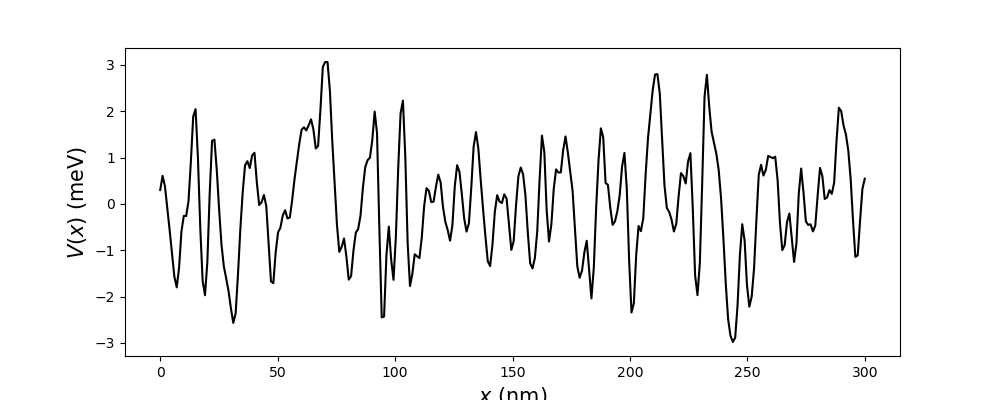

In [3]:
sigma = 70
x0 = 0.0
x1 = params.Length

def Potential(x, V_0):
    return V_0*(
        np.exp(-((int(x/2) - x0) ** 2) / (2 * sigma**2))
        + np.exp(-((x1 - int(x/2)) ** 2) / (2 * sigma**2))
    )

x = np.linspace(0.0,params.Length,params.Length)
pot_V = []
for i in range(0,2*params.Length,2):
    pot_V.append(Potential(i, V0))
pot_V = np.array(pot_V)
#V_dis = pot_V
params = ModelParams(Disorder=V_dis)
fig, ax_v = plt.subplots(figsize=(10, 4))
ax_v.plot(x, params.Disorder, label=r"$V(x)$", color="black")
ax_v.set_xlabel(r"$x$ (nm)", fontsize=15)
ax_v.set_ylabel(r"$V(x)$ (meV)", fontsize=15)
plt.show()

In [4]:
##Local Parameters##
mu_loc = 2.85
Ez_loc = 0.76
V_QD_low_loc = 2.84
V_QD_high_loc = 2.92
V_QD_points_loc = 50
phi_low_loc = 0.0
phi_high_loc = 2.0*np.pi
phi_points_loc = 500
gam_low_loc = 0.2
gam_high_loc = 1.25
gam_points_loc = 50
w_left_loc = 0.025
w_right_loc = 0.025
V_QD_loc = 2.9
No_QD_loc = False
params = ModelParams(
    mu=mu_loc, 
    Ez=Ez_loc, 
    w_left=w_left_loc, 
    w_right=w_right_loc, 
    V_QD_low=V_QD_low_loc, 
    V_QD_high=V_QD_high_loc, 
    V_QD_points=V_QD_points_loc, 
    Ez_low=gam_low_loc, 
    Ez_high=gam_high_loc, 
    Ez_points=gam_points_loc,
    phi_low=phi_low_loc,
    phi_high=phi_high_loc,
    phi_points=phi_points_loc, 
    V_QD=V_QD_loc,
    Disorder=V_dis, 
    chirality_op=S,
                     )
gam_range_loc = np.linspace(gam_low_loc, gam_high_loc, gam_points_loc)
vqd_range_loc = np.linspace(V_QD_low_loc, V_QD_high_loc, V_QD_points_loc)
tunnel_strength_range = np.linspace(0.001, 0.5, V_QD_points_loc)

In [5]:
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True)#np.zeros((50,gam_points_loc))##
#pfaf_1d = np.zeros(gam_points_loc)
#for idx in tqdm(range(gam_points_loc)):
#    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=No_QD_loc, params=params)
#mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=No_QD_loc, params=params)
#C_vs_phi_even, C_vs_phi_odd = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=40)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
#L_vs_phi_even_P, L_vs_phi_even_D, L_vs_phi_odd_P, L_vs_phi_odd_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=40)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=No_QD_loc)
E_vs_vqd, _, _ = Energy_spectrum_v_VQD(mu=mu_loc, Ez=Ez_loc, phi=0.0, params=params)

V_QD eigs: 100%|██████████| 250/250 [00:00<00:00, 64999.75it/s]


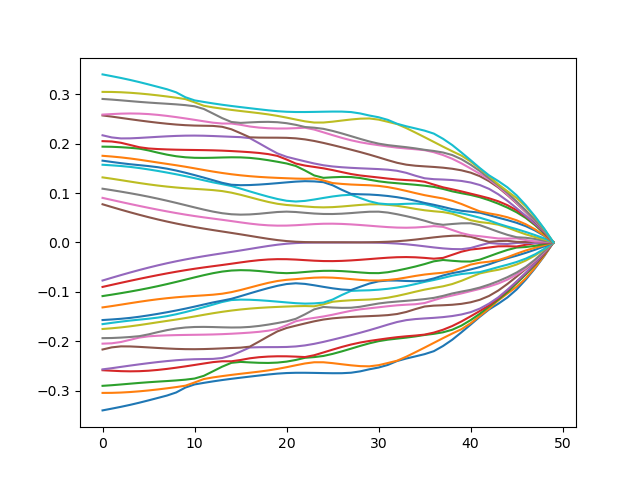

In [7]:
fig, ax_es = plt.subplots()
ax_es.plot(Energy_spectra)
plt.show()

In [50]:
delta_E_vqd_signed, delta_E_phi_signed = [] ,[]
for i in tqdm(range(V_QD_points_loc)):
    params.Ez = gam_range_loc[i]
    params.w_right = 0.025
    params.w_left = 0.025
    E_pos, E_neg = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, params=params)
    delta_E_vqd_signed.append(E_pos-E_neg)
    params.w_right = tunnel_strength_range[i]
    params.w_left = tunnel_strength_range[i]
    params.Ez = 0.88
    E_pos, E_neg = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc, params=params)
    delta_E_phi_signed.append(E_pos-E_neg)

100%|██████████| 50/50 [14:58<00:00, 17.96s/it]


In [ ]:
from joblib import Parallel, delayed
from copy import deepcopy
import numpy as np

def worker(i, mu_loc, Ez_loc, params, tunnel_strength_range, gam_range_loc):
    p0 = deepcopy(params)

    p1 = deepcopy(params)
    p1.Ez = gam_range_loc[i]
    p1.w_right = w_right_loc
    p1.w_left = w_left_loc
    E_pos, E_neg = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, params=p1)
    v = E_pos - E_neg

    p2 = deepcopy(params)
    p2.w_right = p2.w_left = tunnel_strength_range[i]
    p2.V_QD = V_QD_loc
    p2.Ez = Ez_loc
    E_pos, E_neg = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc, params=p2)
    w = E_pos - E_neg

    return v, w

# run in parallel (adjust n_jobs)
results = Parallel(n_jobs=6, backend="loky")(
    delayed(worker)(i, mu_loc, Ez_loc, params, tunnel_strength_range, gam_range_loc)
    for i in range(V_QD_points_loc)
)

delta_E_vqd_signed, delta_E_phi_signed = map(np.array, zip(*results))

100%|██████████| 50/50 [00:01<00:00, 36.49it/s]


In [5]:
def worker_ts_sweep(w_avg, mu_loc, gam_range_loc, No_QD_loc, params):
    """Worker function to compute Topological_stability for a given tunnel strength"""
    p = deepcopy(params)
    p.w_left = p.w_right = w_avg
    Ts_gam_sweep = []
    for Ez0 in gam_range_loc:
        Ts_gam_sweep.append(Topological_stability(mu_loc, Ez0, No_QD_loc, p))
    return Ts_gam_sweep

# Parallelize the outer loop (tunnel strength range)
Ts_sweep = Parallel(n_jobs=6, backend="loky")(
    delayed(worker_ts_sweep)(w_avg, mu_loc, gam_range_loc, No_QD_loc, deepcopy(params))
    for w_avg in tqdm(tunnel_strength_range)
)

100%|██████████| 50/50 [05:10<00:00,  6.22s/it]


In [58]:
delta_E_phi_signed, delta_E_vqd_signed = np.array(delta_E_phi_signed), np.array(delta_E_vqd_signed)
print(delta_E_vqd_signed.shape)

(50, 50)


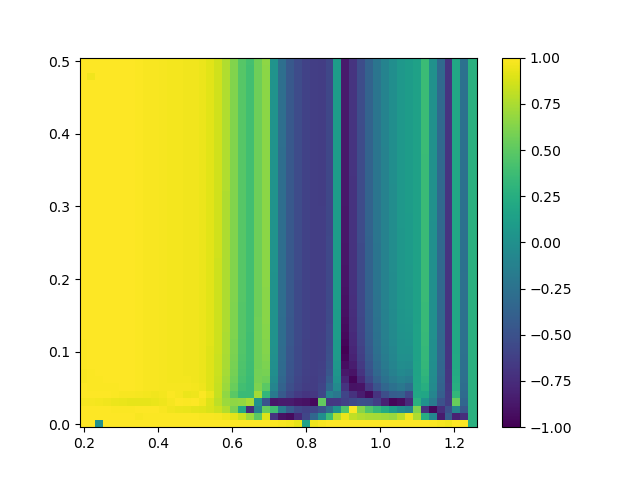

In [8]:
fig, ax_dens = plt.subplots()
angles = np.linspace(0.0, 2.0, params.phi_points)
pcm = ax_dens.pcolor(gam_range_loc, tunnel_strength_range, Ts_sweep, vmin = -1.0, vmax = 1.0)
plt.colorbar(pcm)
plt.show()

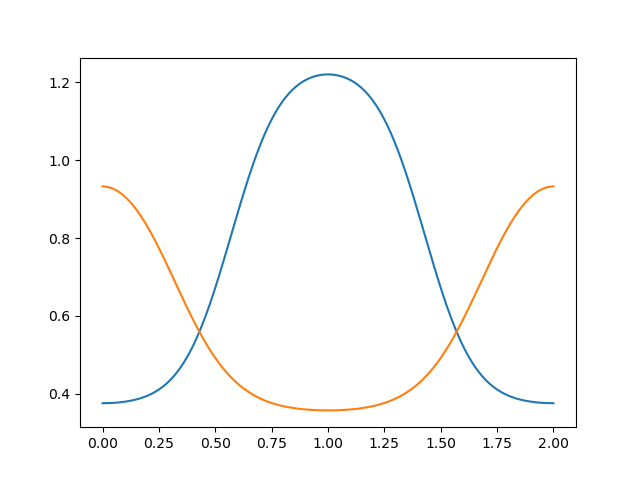

In [6]:
fig, ax_S = plt.subplots()
angles = np.linspace(0.0, 2.0, params.phi_points)
ax_S.plot(angles,C_vs_phi_even)
ax_S.plot(angles,C_vs_phi_odd)
plt.show()

phi eigs: 100%|██████████| 500/500 [00:00<00:00, 36936.00it/s]


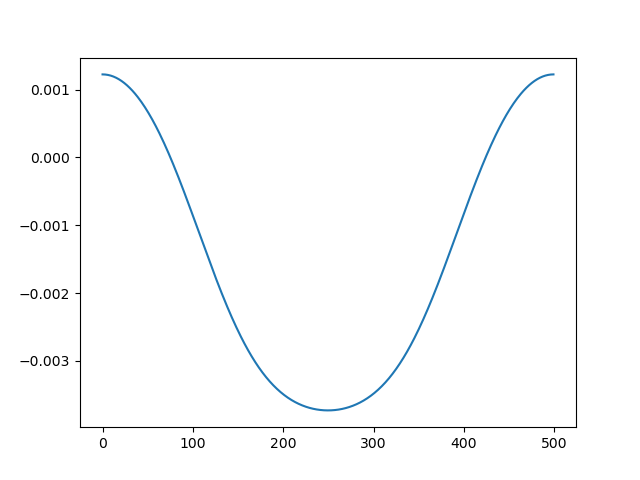

In [5]:
E0_p, E0_n = Energy_tracker_phi(mu_loc, Ez_loc, params) #Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=1.0*np.pi, params=params)
#E_spec_vqd, _, _ = Energy_spectrum_v_VQD(mu_loc, Ez_loc, phi=np.pi, params=params)
#print(E_spec_vqd.shape)
fig, ax_E = plt.subplots()
#ax_E.plot(vqd_range_loc, E_spec_vqd)
ax_E.plot(E0_p)
#ax_E.set_ylim(-0.014,0.014)
plt.show()

In [15]:
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=No_QD_loc)

100%|██████████| 150/150 [00:19<00:00,  7.60it/s]


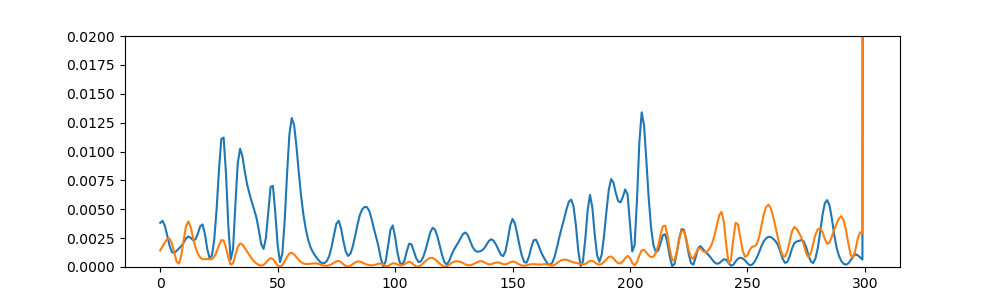

In [17]:
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.29*np.pi, No_QD=No_QD_loc, params=params)
fig, ax_wf = plt.subplots(figsize=(10,3))
ax_wf.plot(mf_wf1)
ax_wf.plot(mf_wf2)
ax_wf.set_ylim(0.0,0.020)
plt.show()

In [70]:
C_vs_VQD_phi_0, C_vs_VQD_phi_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=100)
L_vs_VQD_phi_P_0, L_vs_VQD_phi_D_0, L_vs_VQD_phi_P_pi, L_vs_VQD_phi_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=100)

100%|██████████| 150/150 [02:21<00:00,  1.06it/s]


In [36]:
##Generate txt file
C_vs_phi_even, C_vs_phi_odd = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
L_vs_phi_even_P, L_vs_phi_even_D, L_vs_phi_odd_P, L_vs_phi_odd_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
##---With QD couplings---##
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=False)
pfaf_1d = np.zeros(gam_points_loc)
for idx in tqdm(range(gam_points_loc)):
    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=False, params=params)
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=False, params=params)
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=False)
##Saving results with QD included-
parameter_value = "wd_mu_05_gam_065"
np.savetxt("Impedance_calc_files/Energy_spectra_w_QD_"+parameter_value+".txt",Energy_spectra)
np.savetxt("Impedance_calc_files/Pfafian_spectra_w_QD_"+parameter_value+".txt",pfaf_1d)
np.savetxt("Impedance_calc_files/E_vs_phi_w_QD_"+parameter_value+".txt",E_vs_phi)
np.savetxt("Impedance_calc_files/Wavefunction_1_w_QD_"+parameter_value+".txt",mf_wf1)
np.savetxt("Impedance_calc_files/Wavefunction_2_w_QD_"+parameter_value+".txt",mf_wf2)
##---Without QD couplings---##
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True)
pfaf_1d = np.zeros(gam_points_loc)
for idx in tqdm(range(gam_points_loc)):
    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=True, params=params)
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=True, params=params)
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=True, end_hopping=True)
##Saving results without QD included-
np.savetxt("Impedance_calc_files/Energy_spectra_wo_QD_"+parameter_value+".txt",Energy_spectra)
np.savetxt("Impedance_calc_files/Pfafian_spectra_wo_QD_"+parameter_value+".txt",pfaf_1d)
np.savetxt("Impedance_calc_files/E_vs_phi_wo_QD_"+parameter_value+".txt",E_vs_phi)
np.savetxt("Impedance_calc_files/Wavefunction_1_wo_QD_"+parameter_value+".txt",mf_wf1)
np.savetxt("Impedance_calc_files/Wavefunction_2_wo_QD_"+parameter_value+".txt",mf_wf2)
##Common calculations
C_vs_VQD_phi_0, C_vs_VQD_phi_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
L_vs_VQD_phi_P_0, L_vs_VQD_phi_D_0, L_vs_VQD_phi_P_pi, L_vs_VQD_phi_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
##Saving common files
np.savetxt("Impedance_calc_files/Capacitance_even_"+parameter_value+".txt",C_vs_phi_even)
np.savetxt("Impedance_calc_files/Capacitance_odd_"+parameter_value+".txt",C_vs_phi_odd)
np.savetxt("Impedance_calc_files/Capacitance_v_VQD_phi_0_"+parameter_value+".txt",C_vs_VQD_phi_0)
np.savetxt("Impedance_calc_files/Capacitance_v_VQD_phi_pi_"+parameter_value+".txt",C_vs_VQD_phi_pi)
np.savetxt("Impedance_calc_files/Impedance_even_D_"+parameter_value+".txt",L_vs_phi_even_D)
np.savetxt("Impedance_calc_files/Impedance_even_P_"+parameter_value+".txt",L_vs_phi_even_P)
np.savetxt("Impedance_calc_files/Impedance_odd_D_"+parameter_value+".txt",L_vs_phi_odd_D)
np.savetxt("Impedance_calc_files/Impedance_odd_P_"+parameter_value+".txt",L_vs_phi_odd_P)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_0_D_"+parameter_value+".txt",L_vs_VQD_phi_D_0)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_0_P_"+parameter_value+".txt",L_vs_VQD_phi_P_0)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_pi_D_"+parameter_value+".txt",L_vs_VQD_phi_D_pi)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_pi_P_"+parameter_value+".txt",L_vs_VQD_phi_P_pi)

100%|██████████| 150/150 [06:10<00:00,  2.47s/it]


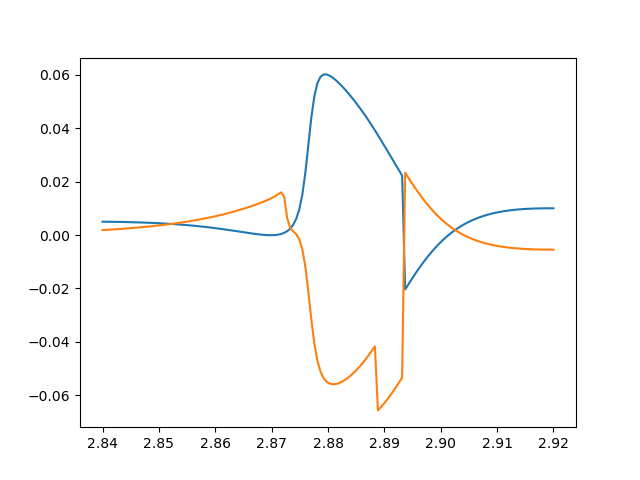

In [76]:
fig, ax_trial = plt.subplots()
#ax_trial.plot(vqd_range_loc, C_vs_VQD_phi_0)
#ax_trial.plot(vqd_range_loc, -C_vs_VQD_phi_pi)
ax_trial.plot(vqd_range_loc, L_vs_VQD_phi_P_0+L_vs_VQD_phi_D_0)
ax_trial.plot(vqd_range_loc, -(L_vs_VQD_phi_P_pi+L_vs_VQD_phi_D_0))
plt.show()

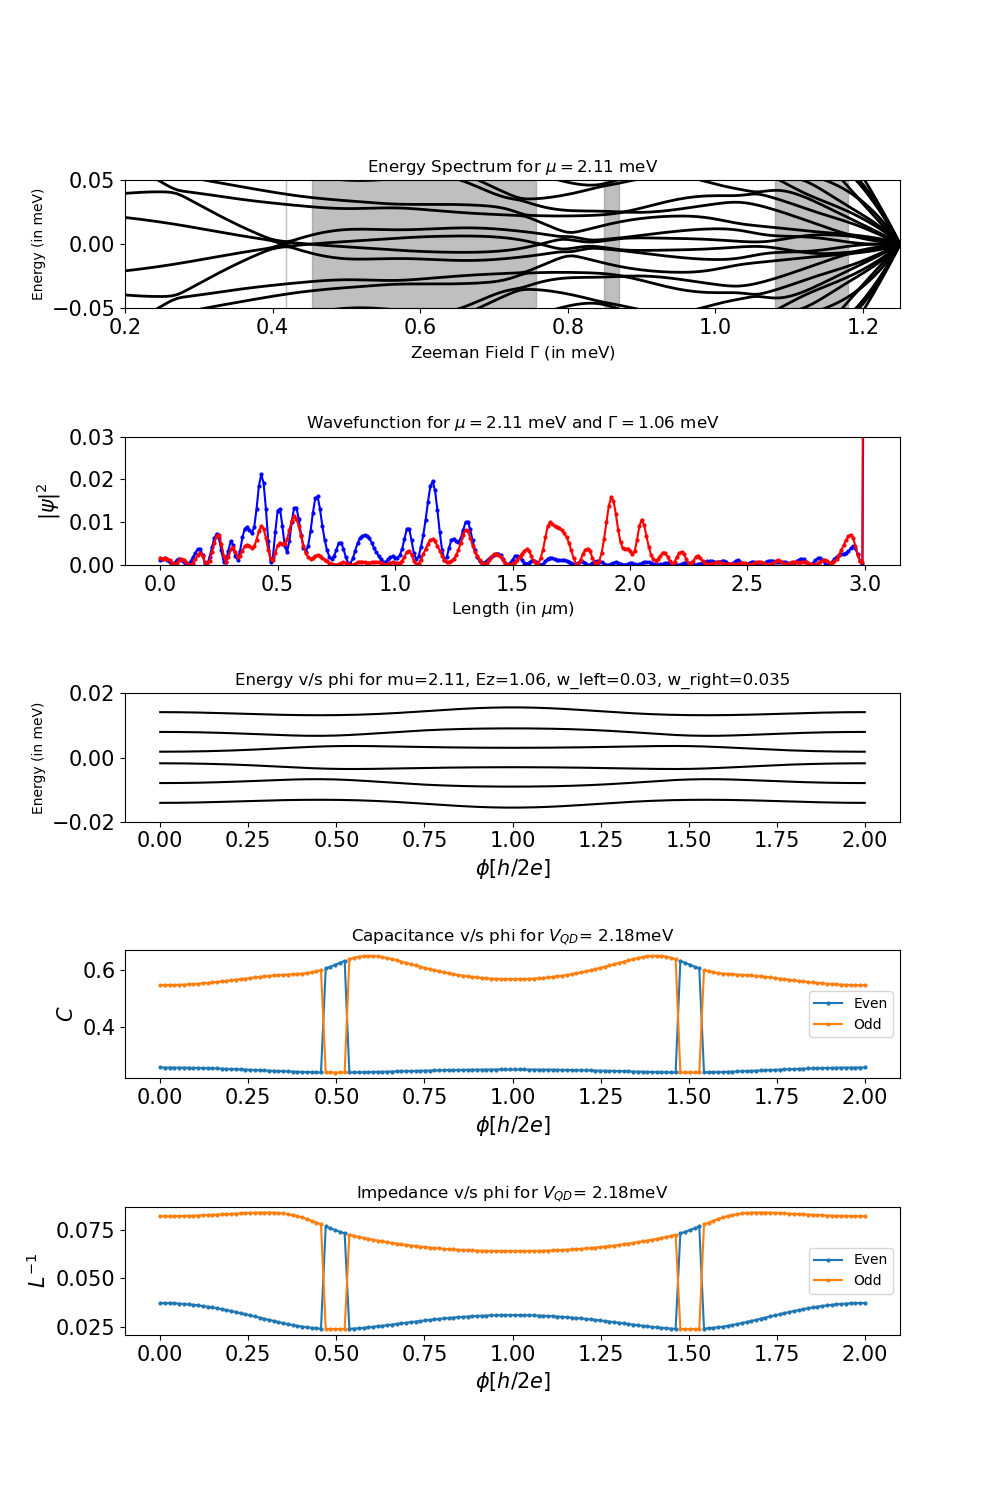

In [59]:
##Plotting all quantities together
fig = plt.figure(figsize=(10, 15))
gs = GridSpec(5,1, figure=fig, hspace=1.)

local_length = params.Length
if not No_QD_loc:
        local_length = params.Length + 1
wire_length = np.linspace(0.0,3.0,local_length)
#angles = np.linspace(params.phi_low, params.phi_high, params.phi_points)
angles = np.linspace(0.0, 2.0, params.phi_points)

ax1 = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        ax1.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax1.set_ylim(-0.05,0.05)
ax1.fill_between(gam_range_loc, -0.05, 0.05, where=(pfaf_1d<0.0), color='gray', alpha=0.5)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_ylabel("Energy (in meV)")
ax1.set_xlabel(r"Zeeman Field $\Gamma$ (in meV)", fontsize=12)
ax1.set_xlim(gam_low_loc,gam_high_loc)
ax1.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(wire_length, mf_wf1, 'o-', color='blue', markersize=2.0)
ax2.plot(wire_length, mf_wf2, 'o-', color='red', markersize=2.0)
ax2.set_ylim(0.0, 0.03)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.set_ylabel(r"$\vert\psi\vert^2$", fontsize=15)
ax2.set_xlabel(r"Length (in $\mu$m)", fontsize=12)
ax2.set_title(r"Wavefunction for $\mu = $"+str(np.round(mu_loc,2))+r" meV and $\Gamma = $"+str(np.round(Ez_loc,2))+" meV")

ax3e = fig.add_subplot(gs[2,0])
for i in range(len(E_vs_phi[0])):
        ax3e.plot(angles, E_vs_phi[:, i], "k", lw=1.5)
ax3e.set_ylim(-0.02,0.02)
ax3e.tick_params(axis='both', which='major', labelsize=15)
ax3e.set_ylabel(r"Energy (in meV)")
ax3e.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3e.set_title(f"Energy v/s phi for mu={mu_loc}, Ez={Ez_loc}, w_left={w_left_loc}, w_right={w_right_loc}")

#Add parity resolved arrays
angle_1 = 0.4595#0.41
angle_2 = 0.5297
angle_3 = 1.4674
angle_4 = 1.5366#1.59
condition_switch = lambda i: False#((angles[i]>=angle_1) and (angles[i]<=angle_4))
condition_double = lambda i: ((angles[i]>=angle_1 and angles[i]<=angle_2) or (angles[i]>=angle_3 and angles[i]<=angle_4))
Ce_parity_resolved, Co_parity_resolved = np.zeros_like(C_vs_phi_even), np.zeros_like(C_vs_phi_odd)
for i in range(len(C_vs_phi_even)):
        Ce_parity_resolved[i] = C_vs_phi_odd[i] if condition_double(i) else C_vs_phi_even[i]
        Co_parity_resolved[i] = C_vs_phi_even[i] if condition_double(i) else C_vs_phi_odd[i]
ax4 = fig.add_subplot(gs[3,0])
ax4.plot(angles, Ce_parity_resolved, '-o', label='Even', markersize=2.0)
ax4.plot(angles, Co_parity_resolved, '-o', label='Odd', markersize=2.0)
ax4.tick_params(axis='both', which='major', labelsize=15)
ax4.set_title(r"Capacitance v/s phi for $V_{QD}$= "+str(np.round(V_QD_loc,2))+"meV")
ax4.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax4.set_ylabel(r'$C$', fontsize=15)
ax4.legend()


#Add parity resolved arrays
#angle_1 = 0.3
#angle_2 = 0.633
#angle_3 = 1.371
#angle_4 = 1.696
condition_switch = lambda i: False#((angles[i]>=angle_1) and (angles[i]<=angle_4))
condition_double = lambda i: ((angles[i]>=angle_1 and angles[i]<=angle_2) or (angles[i]>=angle_3 and angles[i]<=angle_4))
Le_parity_resolved, Lo_parity_resolved = np.zeros_like(L_vs_phi_even_P), np.zeros_like(L_vs_phi_odd_P)
for i in range(len(C_vs_phi_even)):
        Le_parity_resolved[i] = L_vs_phi_odd_P[i] + L_vs_phi_odd_D[i] if condition_double(i) else L_vs_phi_even_P[i] + L_vs_phi_even_D[i]
        Lo_parity_resolved[i] = L_vs_phi_even_P[i] + L_vs_phi_even_D[i] if condition_double(i) else L_vs_phi_odd_P[i] + L_vs_phi_odd_D[i]
ax5 = fig.add_subplot(gs[4,0])
"""
ax5.plot(vqd, d_C0)
ax5.plot(vqd, d_Cpi)
ax5.tick_params(axis = 'both', labelsize=15)
ax5.set_xlabel(r'$V_{QD} (meV)$', fontsize=15)
ax5.set_ylabel(r'$C$', fontsize=15)
#"""
ax5.plot(angles, Le_parity_resolved, '-o', label='Even', markersize=2.0)
ax5.plot(angles, Lo_parity_resolved, '-o', label='Odd', markersize=2.0)
#ax5.plot(VQD_range, L0, label='L0')
#ax5.plot(VQD_range, LPI, label='Lpi')
ax5.tick_params(axis='both', which='major', labelsize=15)
ax5.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(V_QD_loc,2))+"meV")
ax5.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax5.set_ylabel(r'$L^{-1}$', fontsize=15)
ax5.legend()

#plt.savefig("transport_plots_sanity_checked/Double_crossing_system_profile_mu_22_gamma_0975.pdf")
plt.show()